# Models for Outcomes

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from pathlib import Path
import seaborn as sns
import os
import json
from IPython.display import display, JSON
import matplotlib.pyplot as plt
import math

In [14]:
def plot_histograms(df, hyperparameter, bins):

    params = np.sort(df[hyperparameter].unique())
    
    n_params = len(params)
    n_cols = 2 if n_params > 1 else 1
    n_rows = math.ceil(n_params / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3), sharex=True)
    axes = axes.flatten()

    for i, param in enumerate(params):
        ax = axes[i]
        param_R2 = df[df[hyperparameter] == param]

        sns.histplot(data=param_R2, x='val_r2_mean', ax=ax, bins=bins)
        ax.set_title(f'{param}')
        ax.set_xlabel('R2')
        ax.set_ylabel("Count")
    fig.tight_layout()
    plt.show()

## Non-extreme outcomes

For modelling relationships between covariates and the average of the outcome variable among all ARs, we use the `xgboost` algorithm and assess variable importance via partial dependence plots at SHAP values.

### Round 1: Snow

In [97]:
with open('rounds/snow_round1_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [98]:
round1_snow = pd.read_csv('rounds/snow_xgb_round1.csv', index_col=False)

In [99]:
round1_snow.iloc[round1_snow.val_r2_mean.idxmax()]

Unnamed: 0                 17726.000000
gamma                          0.010000
max_depth                      5.000000
reg_lambda                    10.000000
min_child_weight               0.000000
subsample_frac                 0.200000
eta                            0.100000
num_boost                    117.000000
shrinkage_factor               0.988108
val_rmse_mean                  0.208395
val_r2_mean                    0.885501
test-r2-mean-ols-shrunk        0.832043
test-r2-mean-ols               0.832028
Name: 17726, dtype: float64

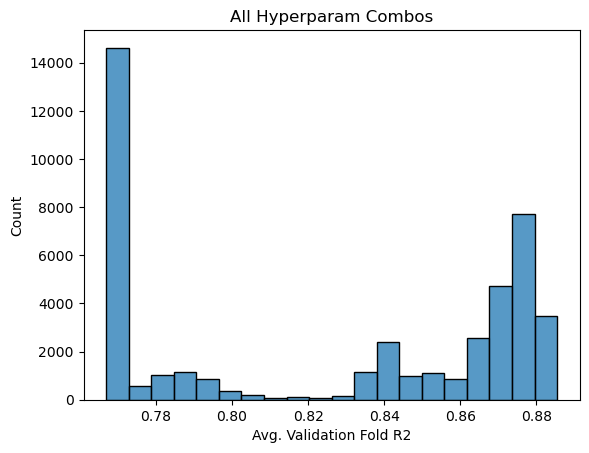

In [100]:
sns.histplot(data=round1_snow, x='val_r2_mean');
plt.title('All Hyperparam Combos')
plt.xlabel('Avg. Validation Fold R2');

Let's first look at `min_child_weight`.

In [104]:
json_data['min_child_weights']

[0, 1, 5, 25, 50, 100, 1000]

In [105]:
round1_snow.groupby('min_child_weight')['val_r2_mean'].max()

min_child_weight
0.0       0.885501
1.0       0.885501
5.0       0.884220
25.0      0.882227
50.0      0.879857
100.0     0.874064
1000.0    0.767057
Name: val_r2_mean, dtype: float64

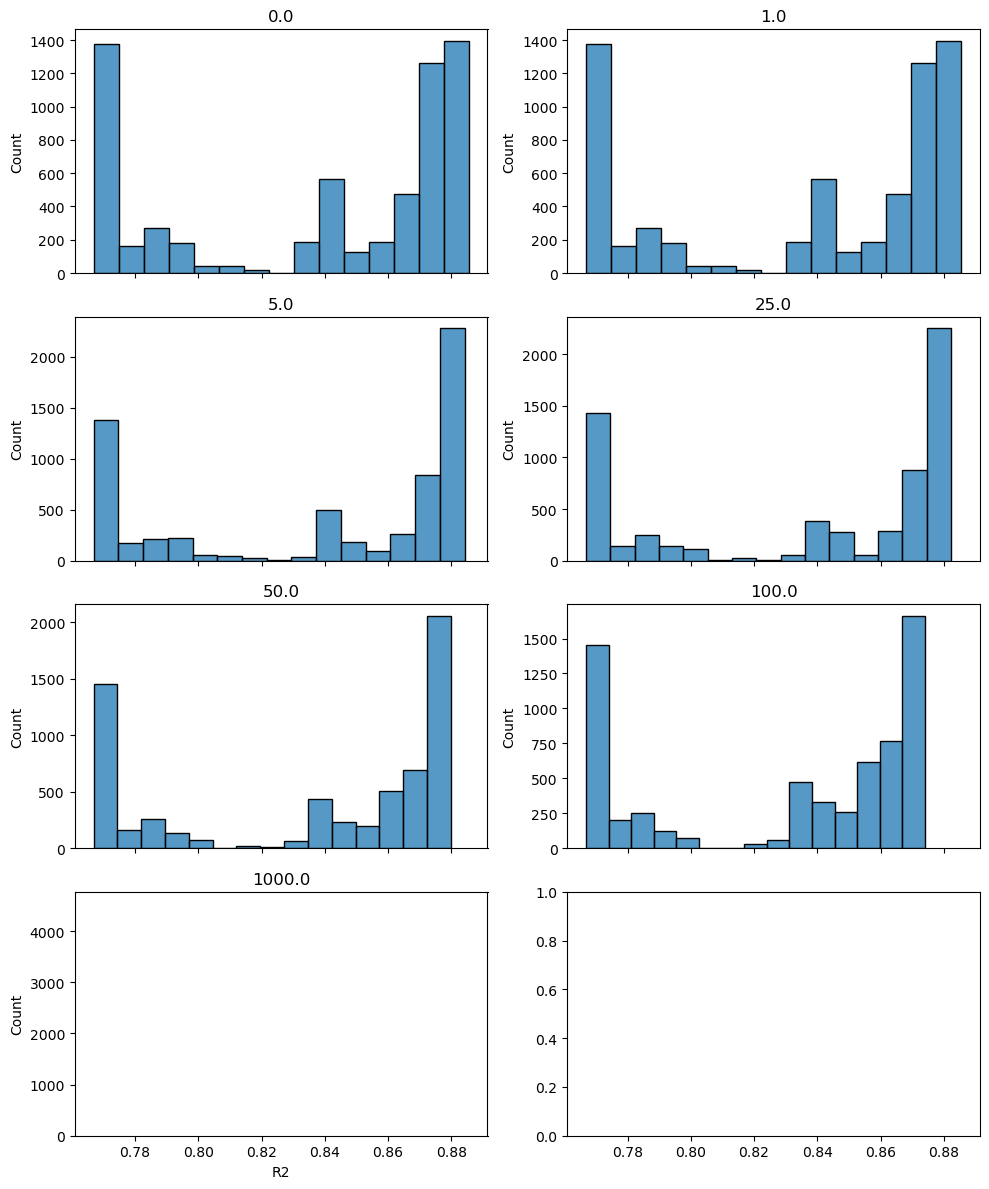

In [106]:
plot_histograms(round1_snow, 'min_child_weight', 15)

So, it seems a plausible range of `min_child_weight` to hone in on is $[0,25]$. The $1000$ values have really low $R^{2}$ for all other hyperparam combos, and $100$ comes close, but the highest the $R^{2}$ gets is smaller than that of $0, 10, 25$. So, let's look at this range.

In [51]:
round1_snow.groupby('gamma')['val_r2_mean'].max()

gamma
0.000      0.884705
0.001      0.884857
0.010      0.885501
1.000      0.882385
10.000     0.817915
100.000    0.767057
Name: val_r2_mean, dtype: float64

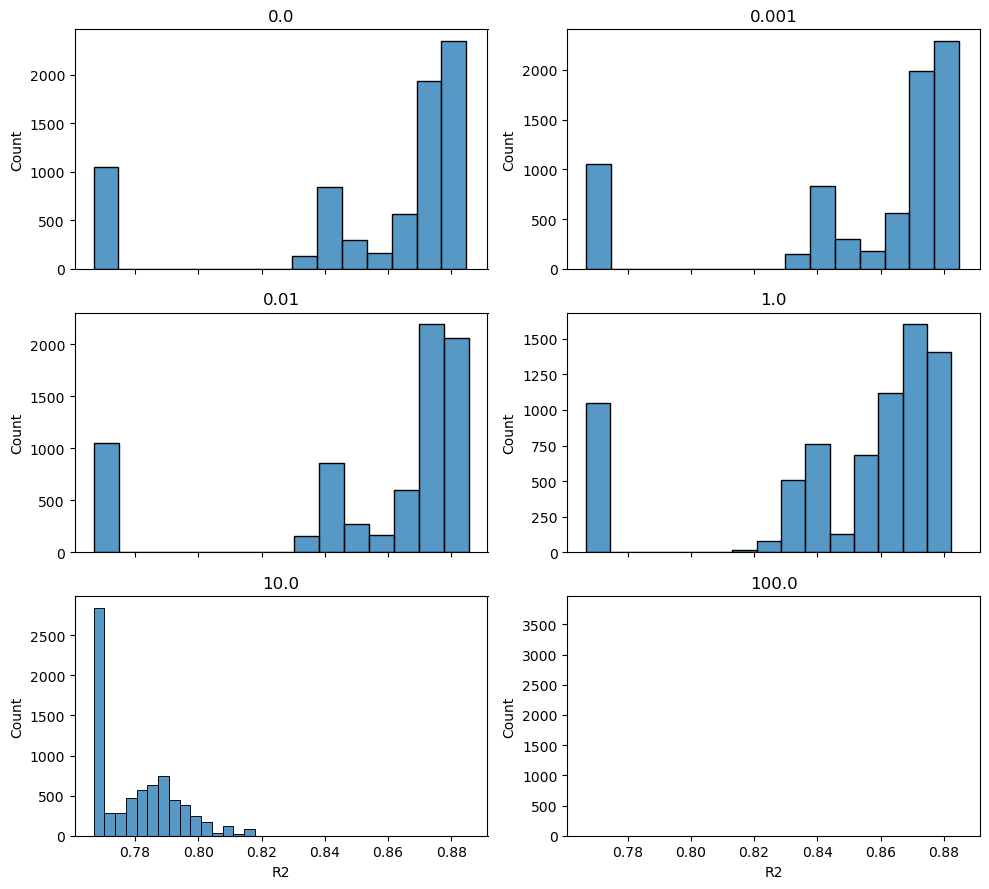

In [108]:
plot_histograms(round1_snow, 'gamma', 15)

Best gammas appear to be smaller than $10$, so let's say $[0,1]$.

In [110]:
round1_snow.groupby('max_depth')['val_r2_mean'].max()

max_depth
1.0     0.847510
3.0     0.885233
5.0     0.885501
7.0     0.884830
10.0    0.882383
15.0    0.882768
Name: val_r2_mean, dtype: float64

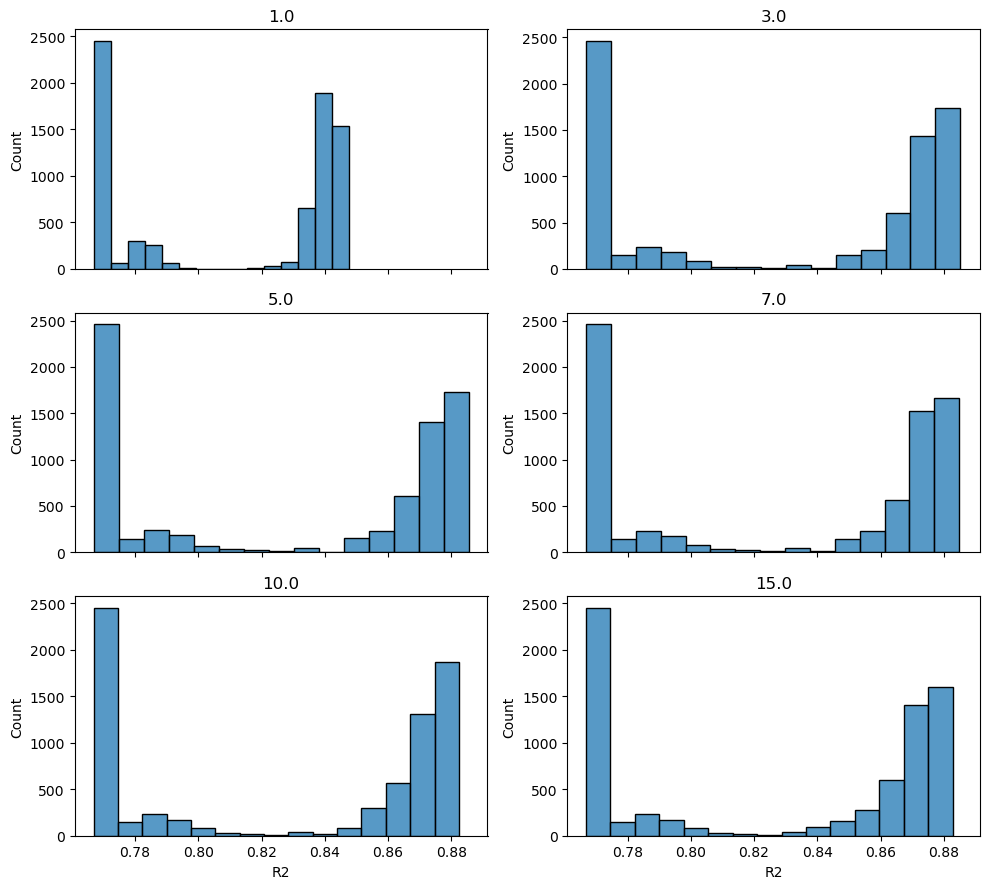

In [109]:
plot_histograms(round1_snow, 'max_depth', 15)

Best `max_depth` appear between $3$ and $10$

In [115]:
round1_snow.groupby('reg_lambda')['val_r2_mean'].max()

reg_lambda
0.000      0.883885
0.001      0.883949
0.010      0.884058
0.100      0.884220
1.000      0.884410
10.000     0.885501
100.000    0.883525
Name: val_r2_mean, dtype: float64

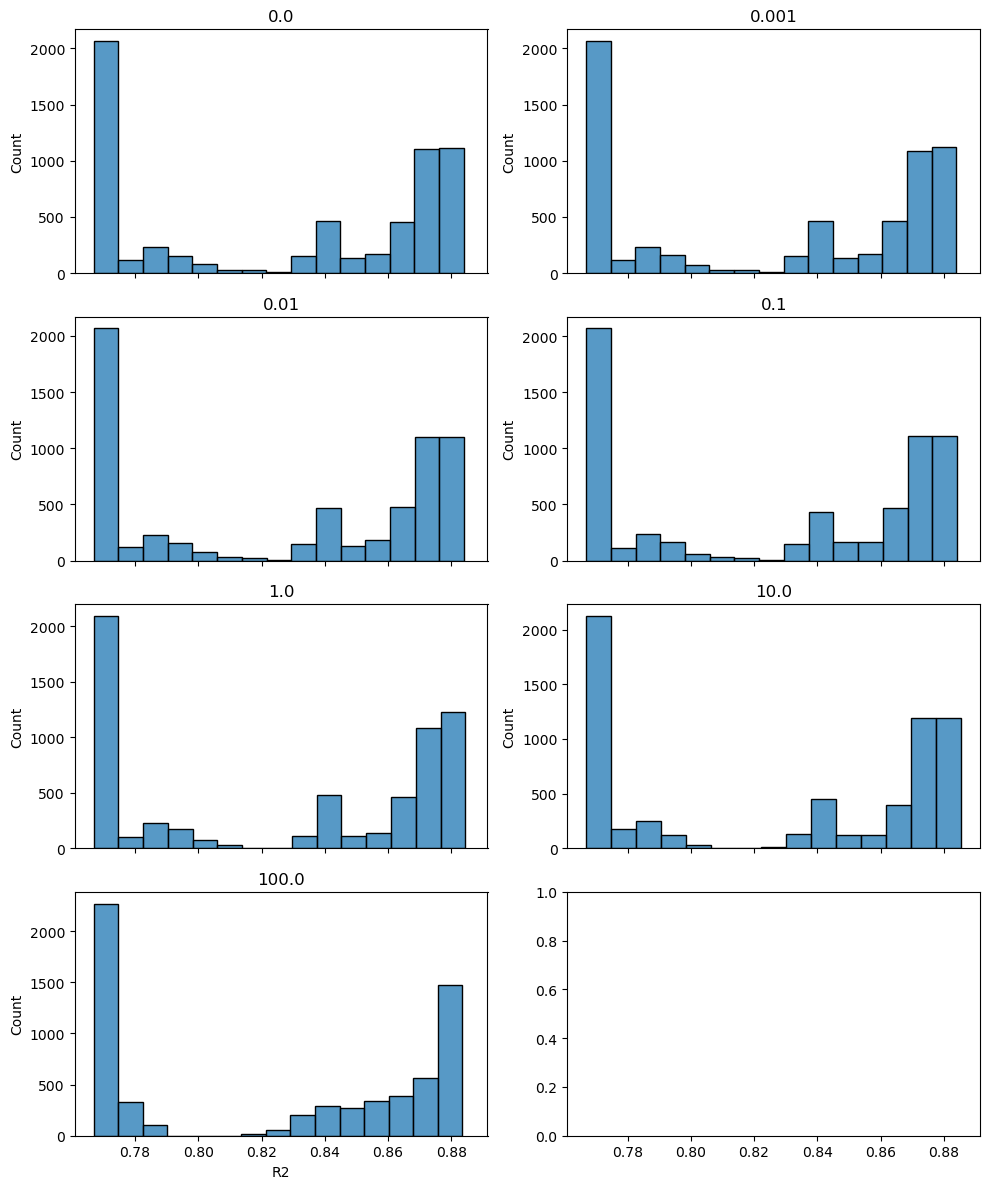

In [116]:
plot_histograms(round1_snow, 'reg_lambda', 15)

Values seem very similar for all $\lambda$. I'm going to do a more evenly spaced grid between $[0, 100]$, instead of logarithmically spaced as before. It seems like with low lambdas, the values are quite similar, then they go up a bit at $\lambda = 10$, and then they start to go down with higher $\lambda$. So, It'll be good to get more values in the $10$s.

In [119]:
round1_snow.groupby('subsample_frac')['val_r2_mean'].max()

subsample_frac
0.2    0.885501
0.4    0.884410
0.6    0.883875
0.8    0.884058
1.0    0.882315
Name: val_r2_mean, dtype: float64

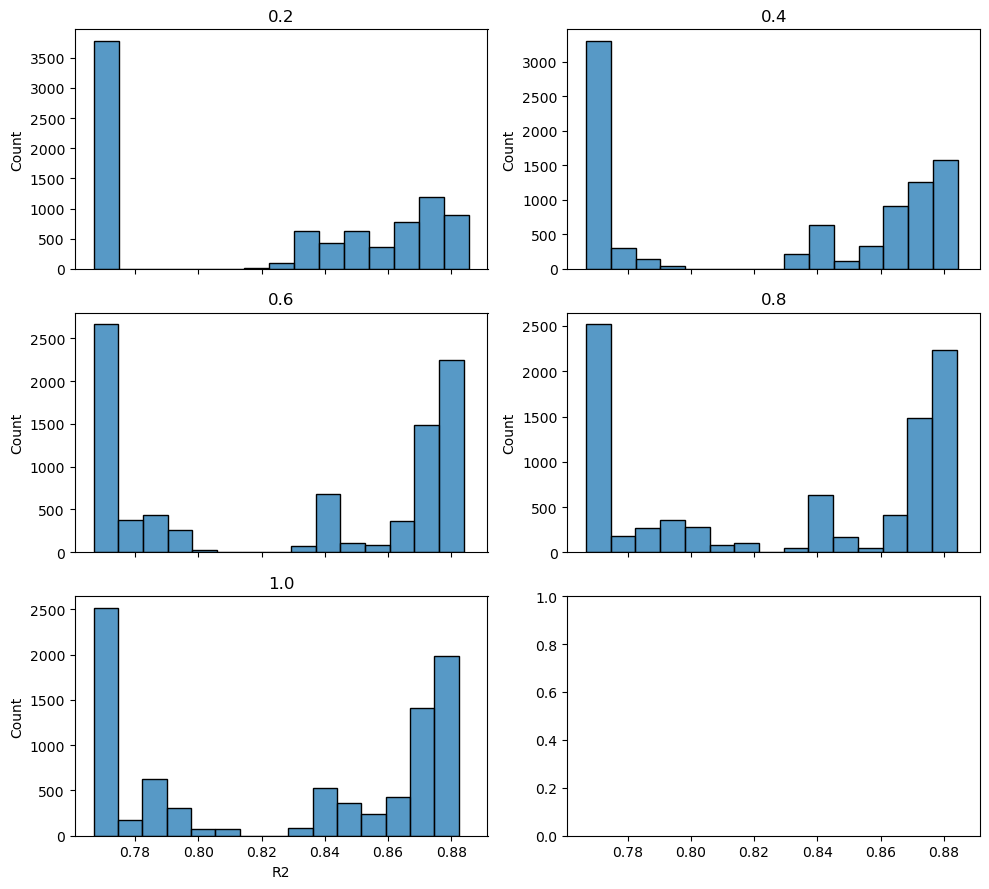

In [121]:
plot_histograms(round1_snow, 'subsample_frac', 15)

Let's refine this to $[0.2, 0.8]$.

In [123]:
round1_snow.groupby('eta')['val_r2_mean'].max()

eta
0.001    0.883398
0.010    0.884058
0.050    0.884830
0.100    0.885501
0.300    0.883525
Name: val_r2_mean, dtype: float64

It seems like the very small learning rates are slightly worse, along with the larger ones. Let's Look between $[0.01, 0.3]$.

#### Round 1 Snow Conclusions

+ `eta`: $[0.01, 0.3]$
+ `subsample_frac`: $[0.2, 0.8]$
+ `reg_lambda`: $[0,100]$ (but more evenly spaced than before)
+ `max_depth`: $[3, 10]$
+ `gamma`: $[0, 1]$
+ `min_child_weight`: $[0,25]$

### Round 2: Snow

In [7]:
with open('rounds/snow_round2_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [8]:
round2_snow = pd.read_csv('rounds/snow_xgb_round2.csv', index_col=False)

In [9]:
round2_snow.iloc[round2_snow.val_r2_mean.idxmax()]

Unnamed: 0                 13466.000000
gamma                          0.200000
max_depth                      8.000000
reg_lambda                    10.000000
min_child_weight               0.000000
subsample_frac                 0.200000
eta                            0.050000
num_boost                    318.000000
shrinkage_factor               0.993419
val_rmse_mean                  0.207547
val_r2_mean                    0.886568
test-r2-mean-ols-shrunk        0.832043
test-r2-mean-ols               0.832028
Name: 13466, dtype: float64

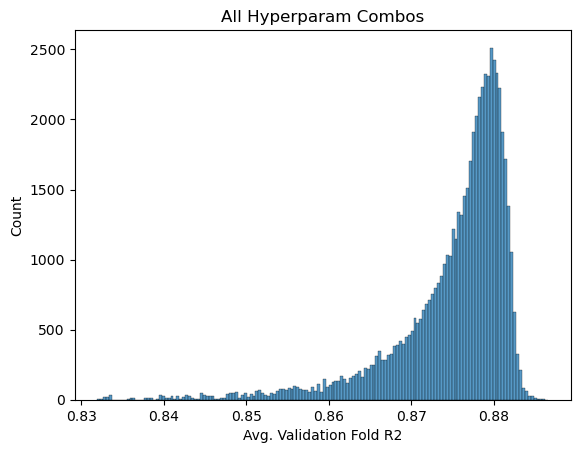

In [6]:
sns.histplot(data=round2_snow, x='val_r2_mean');
plt.title('All Hyperparam Combos')
plt.xlabel('Avg. Validation Fold R2');

Let's first look at `min_child_weight`.

In [10]:
json_data['min_child_weights']

[0, 3, 5, 10, 15, 20, 25]

In [12]:
round2_snow.groupby('min_child_weight')['val_r2_mean'].max()

min_child_weight
0.0     0.886568
3.0     0.885695
5.0     0.884544
10.0    0.883548
15.0    0.884272
20.0    0.882853
25.0    0.882568
Name: val_r2_mean, dtype: float64

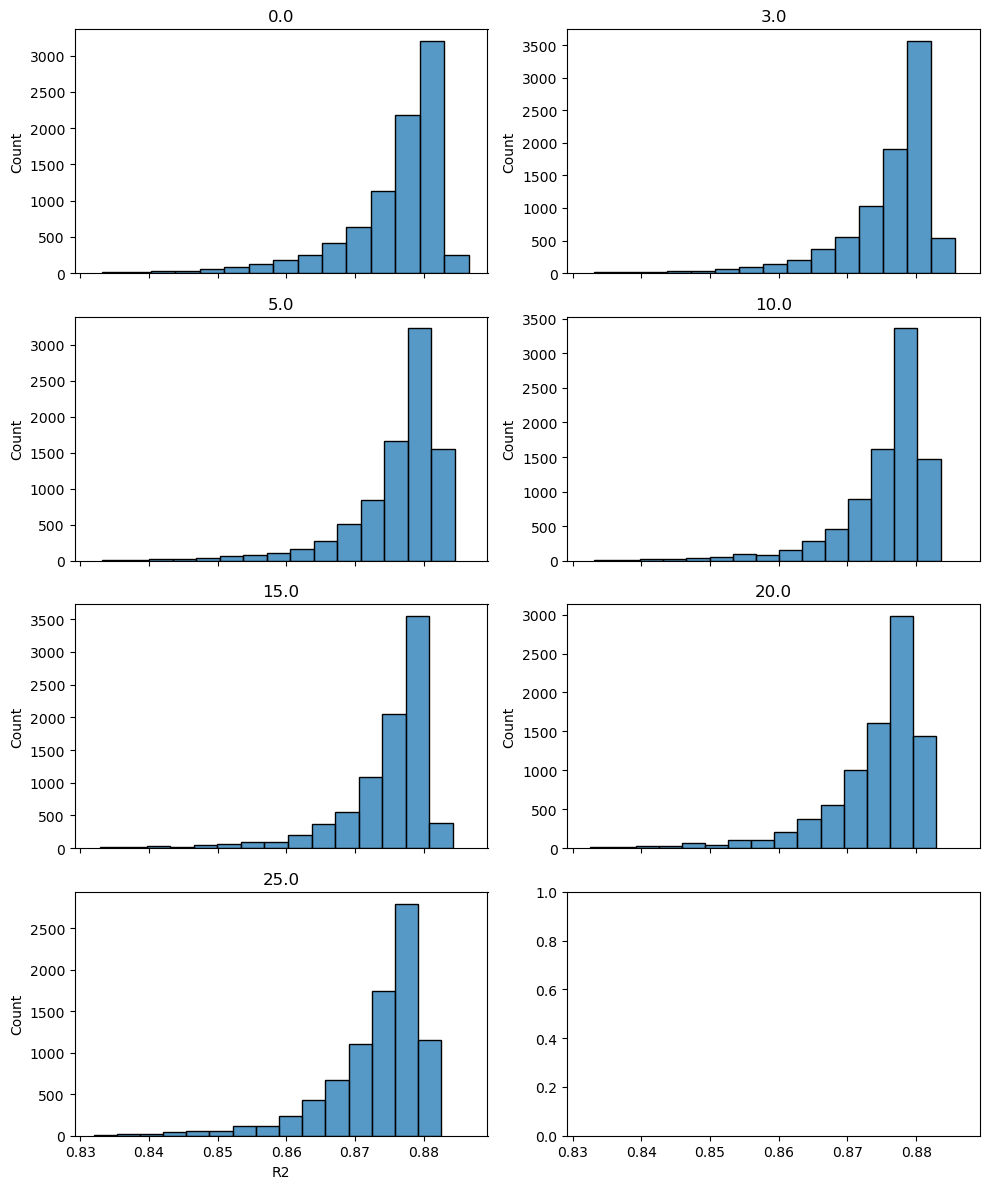

In [15]:
plot_histograms(round2_snow, 'min_child_weight', 15)

So, it seems a plausible range of `min_child_weight` to hone in on is $[0,3]$.

In [17]:
round2_snow.groupby('gamma')['val_r2_mean'].max()

gamma
0.1    0.885884
0.2    0.886568
0.3    0.885223
0.5    0.884373
0.6    0.883966
0.8    0.883805
1.0    0.882412
Name: val_r2_mean, dtype: float64

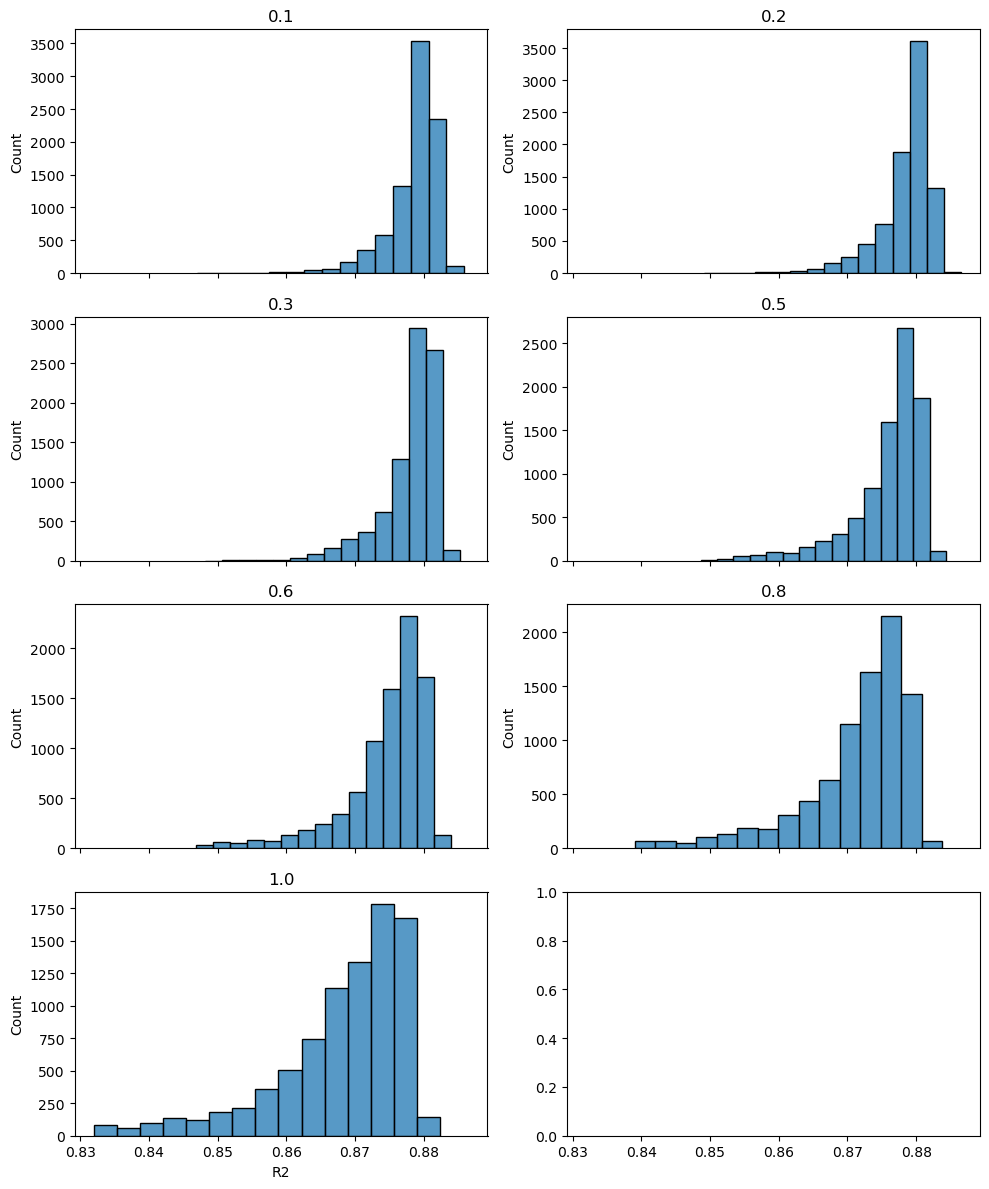

In [19]:
plot_histograms(round2_snow, 'gamma', 15)

Best gammas appear to be smaller than $0.3$, so let's say $[0.1,0.3]$.

In [21]:
round2_snow.groupby('max_depth')['val_r2_mean'].max()

max_depth
3.0     0.885884
5.0     0.885844
7.0     0.885580
8.0     0.886568
10.0    0.885928
Name: val_r2_mean, dtype: float64

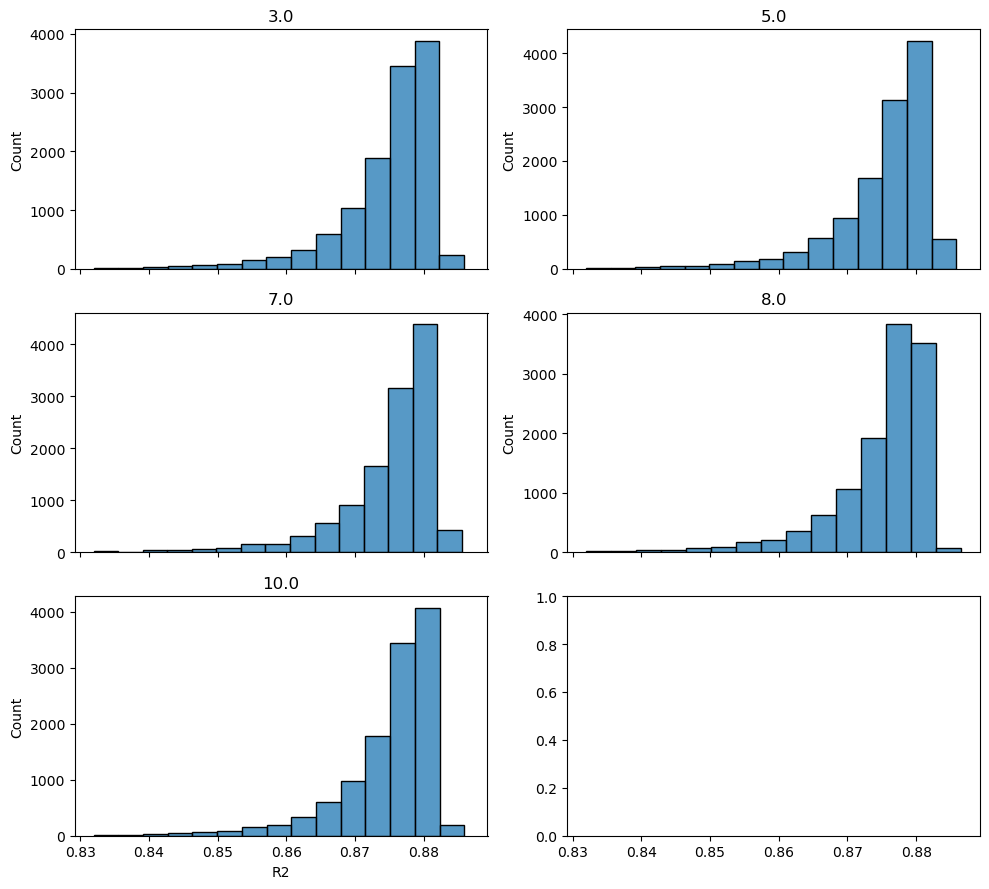

In [22]:
plot_histograms(round2_snow, 'max_depth', 15)

Best `max_depth` appear between $7$ and $10$

In [23]:
round2_snow.groupby('reg_lambda')['val_r2_mean'].max()

reg_lambda
0.0      0.884846
10.0     0.886568
20.0     0.885534
30.0     0.885161
50.0     0.883874
70.0     0.884098
100.0    0.884240
Name: val_r2_mean, dtype: float64

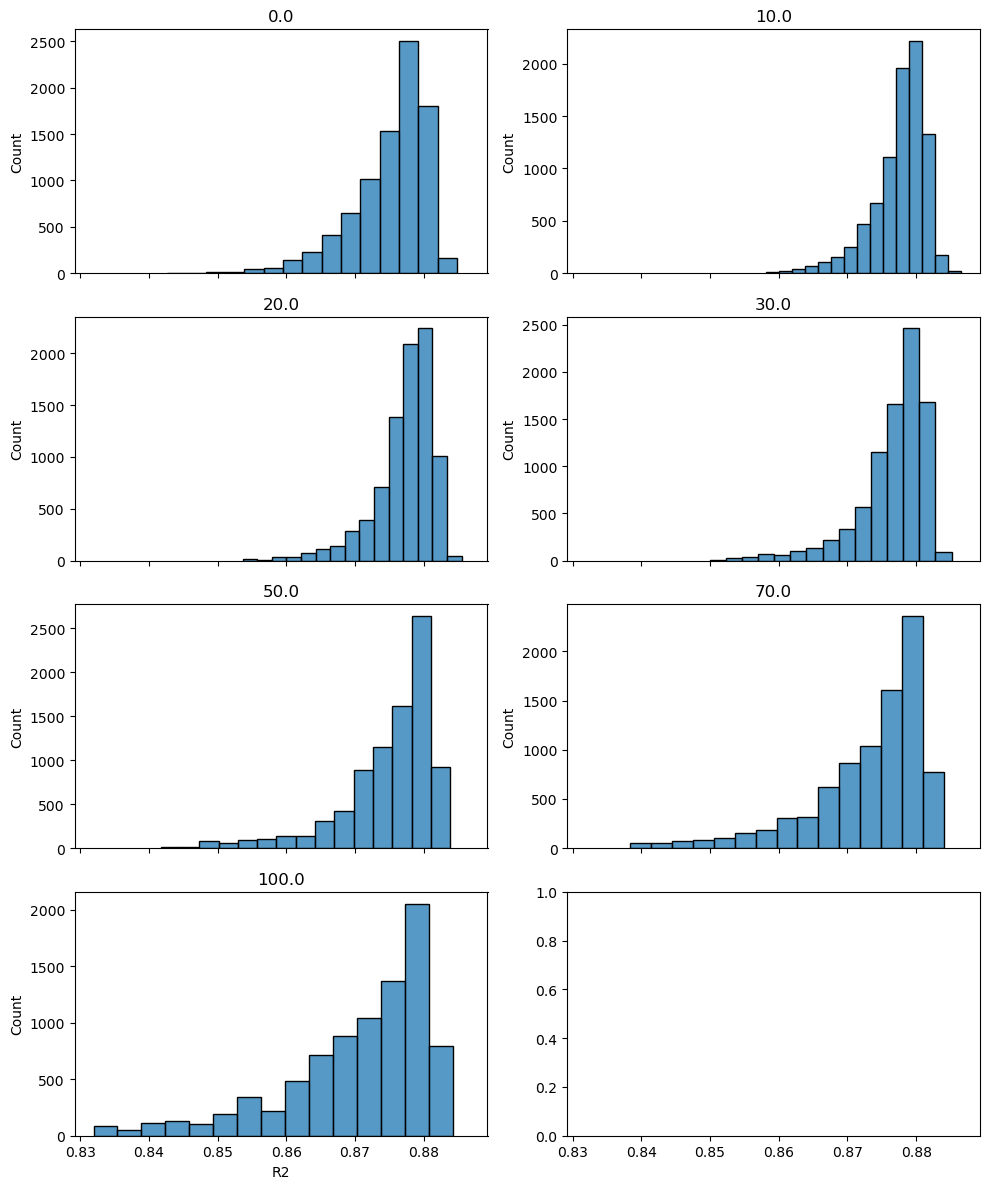

In [25]:
plot_histograms(round2_snow, 'reg_lambda', 15)

Let's hone in on $[0,20]$ for $\lambda$.

In [27]:
round2_snow.groupby('subsample_frac')['val_r2_mean'].max()

subsample_frac
0.2    0.886568
0.3    0.885884
0.4    0.884285
0.5    0.884544
0.6    0.883966
0.7    0.884793
0.8    0.885161
Name: val_r2_mean, dtype: float64

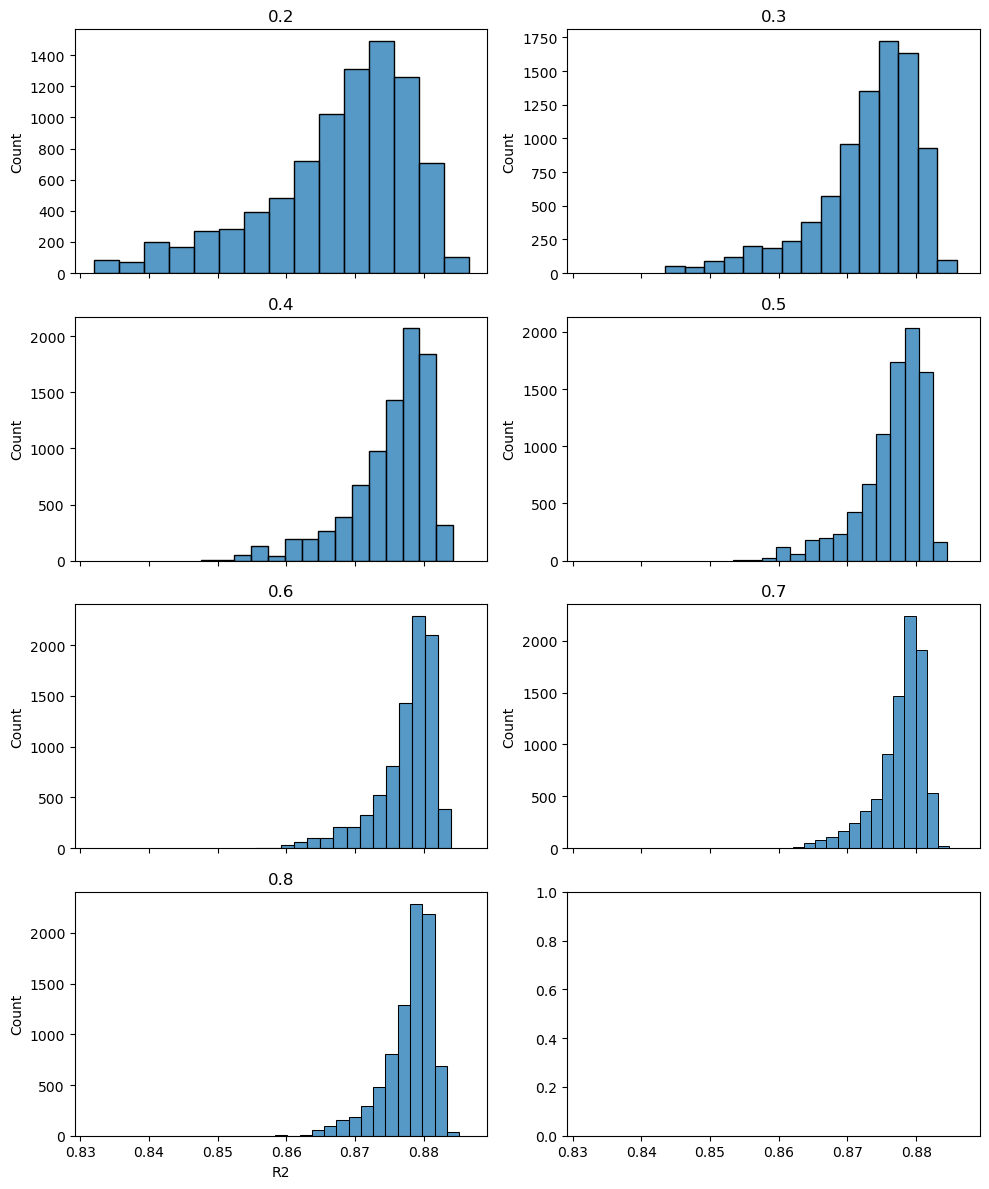

In [29]:
plot_histograms(round2_snow, 'subsample_frac', 15)

Let's refine this to $[0.2, 0.3]$ and $[0.7, 0.8]$. It's interesting because it seems like there are competing effects of the different regularization hyperparameters. With a smaller value of this quantity, there is less regularization needed in the form of higher $\lambda$, and the opposite for higher values of this quantity. Let's include both in the grid and we will see how it goes!

In [35]:
round2_snow.groupby('eta')['val_r2_mean'].max()

eta
0.01    0.883896
0.05    0.886568
0.10    0.885884
0.20    0.885161
0.30    0.884240
Name: val_r2_mean, dtype: float64

Let's Look between $[0.05, 0.2]$.

#### Round 2 Snow Conclusions

+ `eta`: $[0.05, 0.2]$
+ `subsample_frac`: $[0.2, 0.3], [0.7, 0.8]$
+ `reg_lambda`: $[0,20]$ 
+ `max_depth`: $[7, 10]$
+ `gamma`: $[0.1, 0.3]$
+ `min_child_weight`: $[0,3]$

### Round 3: Snow

In [2]:
round3_snow = pd.read_csv('rounds/snow_xgb_round3.csv', index_col=False)

In [8]:
best_performer = round3_snow.iloc[round3_snow['val_r2_mean'].idxmax()]
best_performer = best_performer[['gamma', 'max_depth', 'reg_lambda', 'min_child_weight', 'subsample_frac', 'eta', 'num_boost', 'shrinkage_factor']]

In [9]:
with open("best_snow_xgb.json", "w") as json_file:
    json.dump(best_performer.to_dict(), json_file, indent=4)

### Round 1: Temp

In [126]:
with open('rounds/temp_round1_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [124]:
round1_temp = pd.read_csv('rounds/temp_xgb_round1.csv', index_col=False)

In [127]:
round1_temp.iloc[round1_temp.val_r2_mean.idxmax()]

Unnamed: 0                 40203.000000
gamma                        100.000000
max_depth                      7.000000
reg_lambda                     0.001000
min_child_weight               0.000000
subsample_frac                 0.200000
eta                            0.010000
num_boost                    445.000000
shrinkage_factor               1.010647
val_rmse_mean                  5.078492
val_r2_mean                    0.589215
test-r2-mean-ols-shrunk        0.513920
test-r2-mean-ols               0.513900
Name: 40203, dtype: float64

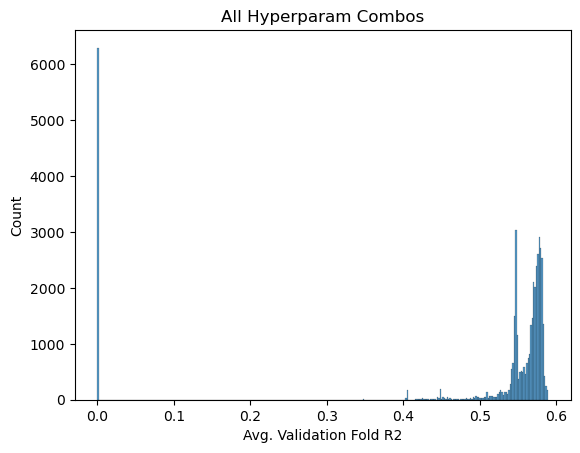

In [128]:
sns.histplot(data=round1_temp, x='val_r2_mean');
plt.title('All Hyperparam Combos')
plt.xlabel('Avg. Validation Fold R2');

In [132]:
round1_temp.groupby('min_child_weight')['val_r2_mean'].max()

min_child_weight
0.0       5.892154e-01
1.0       5.892154e-01
5.0       5.881459e-01
25.0      5.859476e-01
50.0      5.845662e-01
100.0     5.798877e-01
1000.0    8.881784e-17
Name: val_r2_mean, dtype: float64

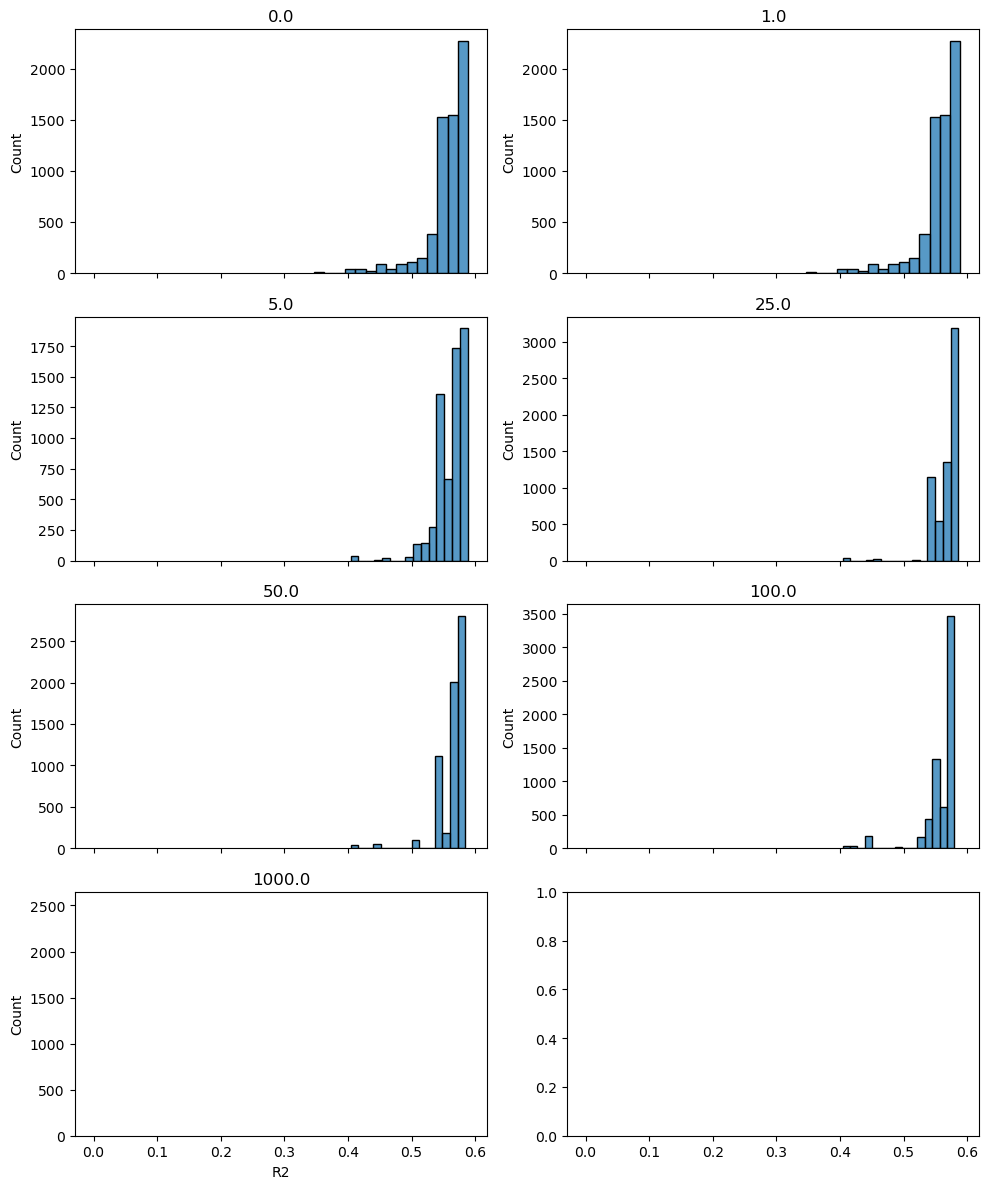

In [131]:
plot_histograms(round1_temp, 'min_child_weight', 15)

Good range for `min_child_weight`: $[0,5]$.

In [133]:
round1_temp.groupby('gamma')['val_r2_mean'].max()

gamma
0.000      0.587914
0.001      0.587914
0.010      0.587914
1.000      0.587968
10.000     0.588795
100.000    0.589215
Name: val_r2_mean, dtype: float64

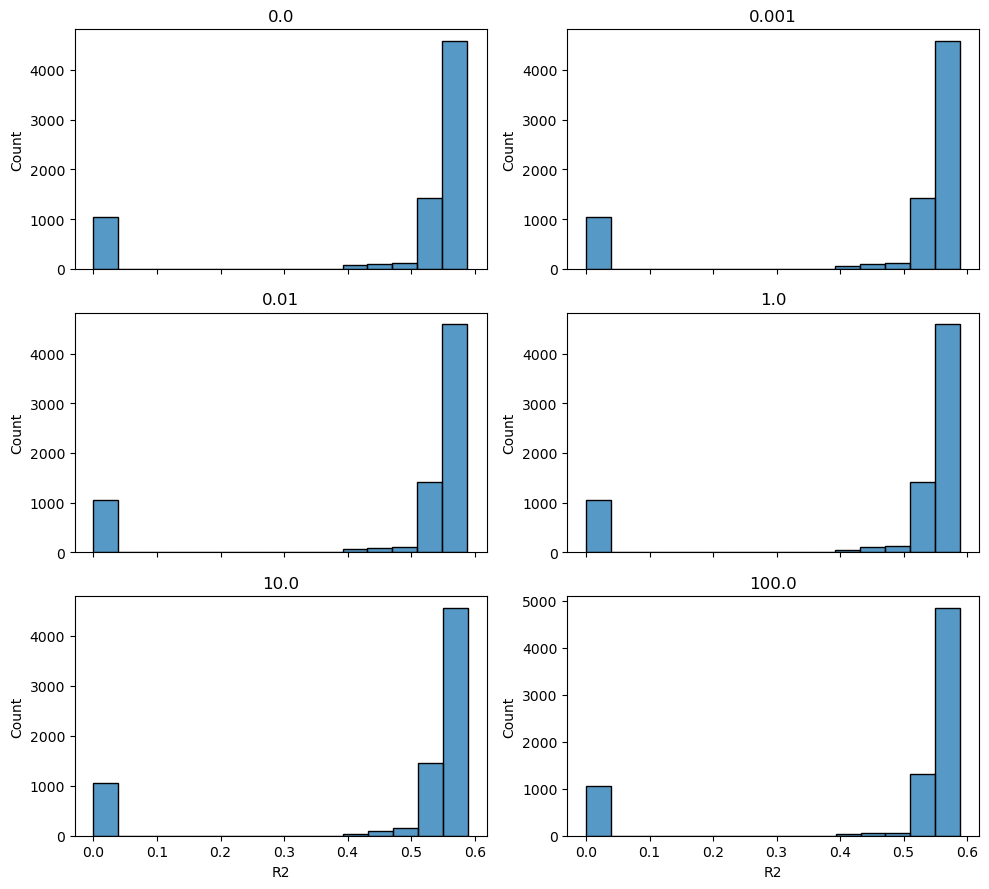

In [134]:
plot_histograms(round1_temp, 'gamma', 15)

Good range for `gamma`: $[1,500]$. Let's just get a little bit higher because it seems like the R2 keeps improving for higher gamma.

In [135]:
round1_temp.groupby('max_depth')['val_r2_mean'].max()

max_depth
1.0     0.549786
3.0     0.584135
5.0     0.589116
7.0     0.589215
10.0    0.588100
15.0    0.587497
Name: val_r2_mean, dtype: float64

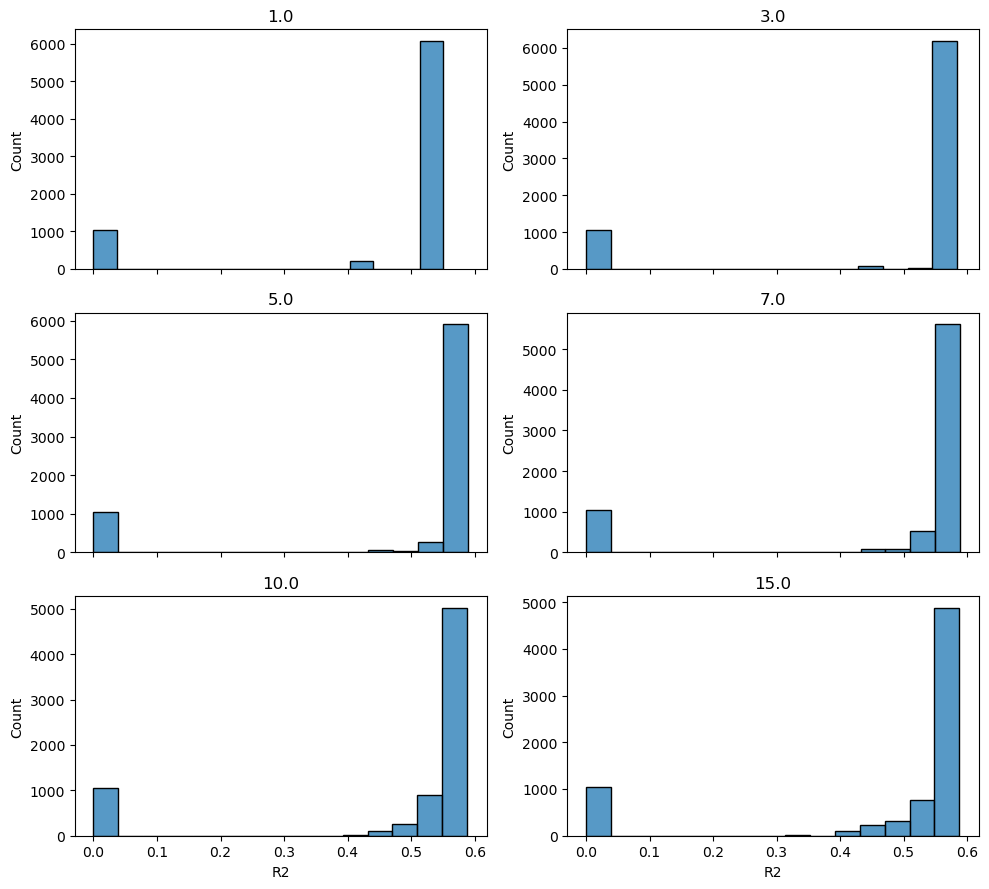

In [138]:
plot_histograms(round1_temp, 'max_depth', 15)

Best `max_depth` appear between $3$ and $10$

In [139]:
round1_temp.groupby('reg_lambda')['val_r2_mean'].max()

reg_lambda
0.000      0.588263
0.001      0.589215
0.010      0.588465
0.100      0.589116
1.000      0.588596
10.000     0.587438
100.000    0.585106
Name: val_r2_mean, dtype: float64

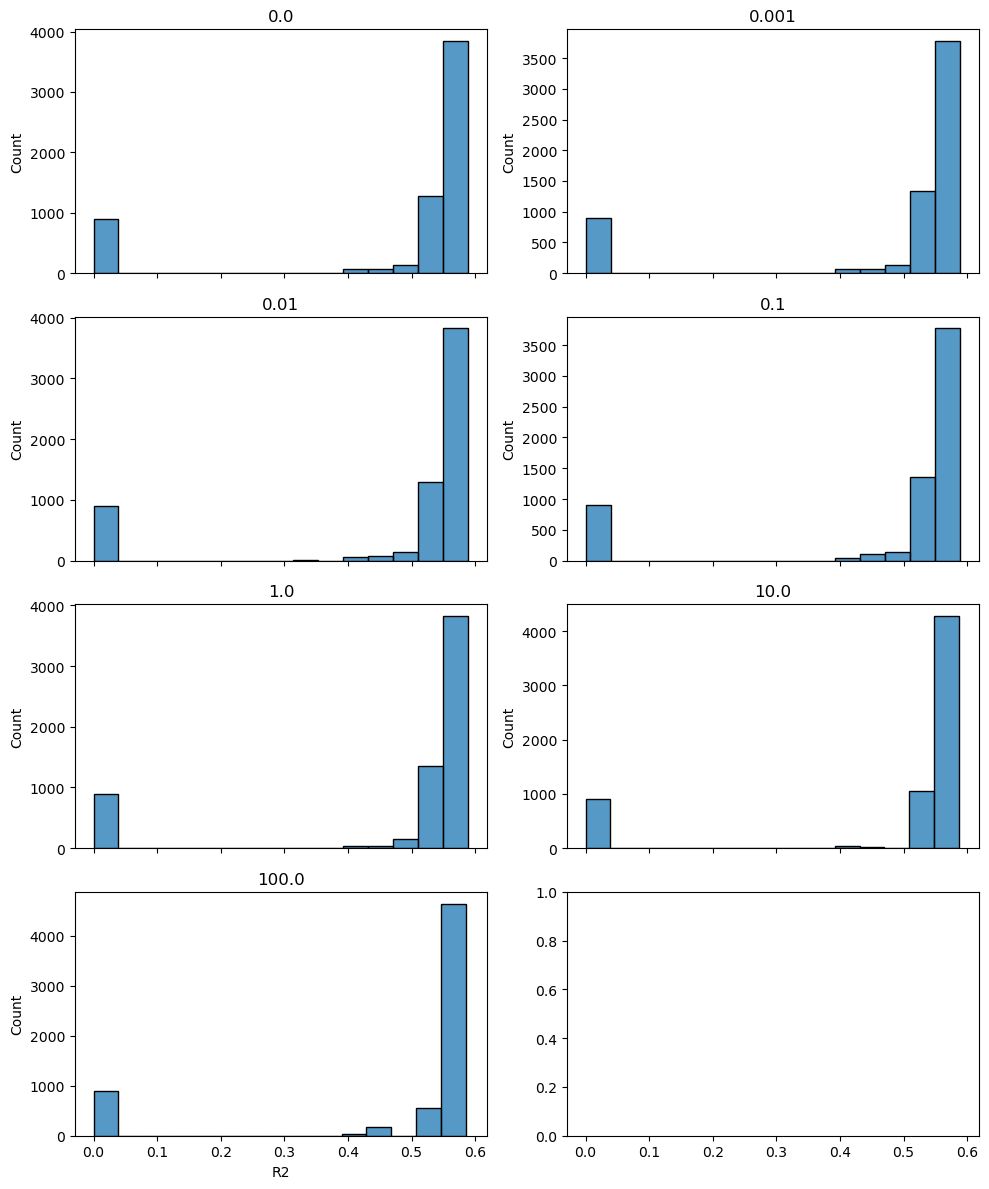

In [140]:
plot_histograms(round1_temp, 'reg_lambda', 15)

Best `reg_lambda` between $[0,1]$.

In [141]:
round1_temp.groupby('subsample_frac')['val_r2_mean'].max()

subsample_frac
0.2    0.589215
0.4    0.588525
0.6    0.587438
0.8    0.584113
1.0    0.577922
Name: val_r2_mean, dtype: float64

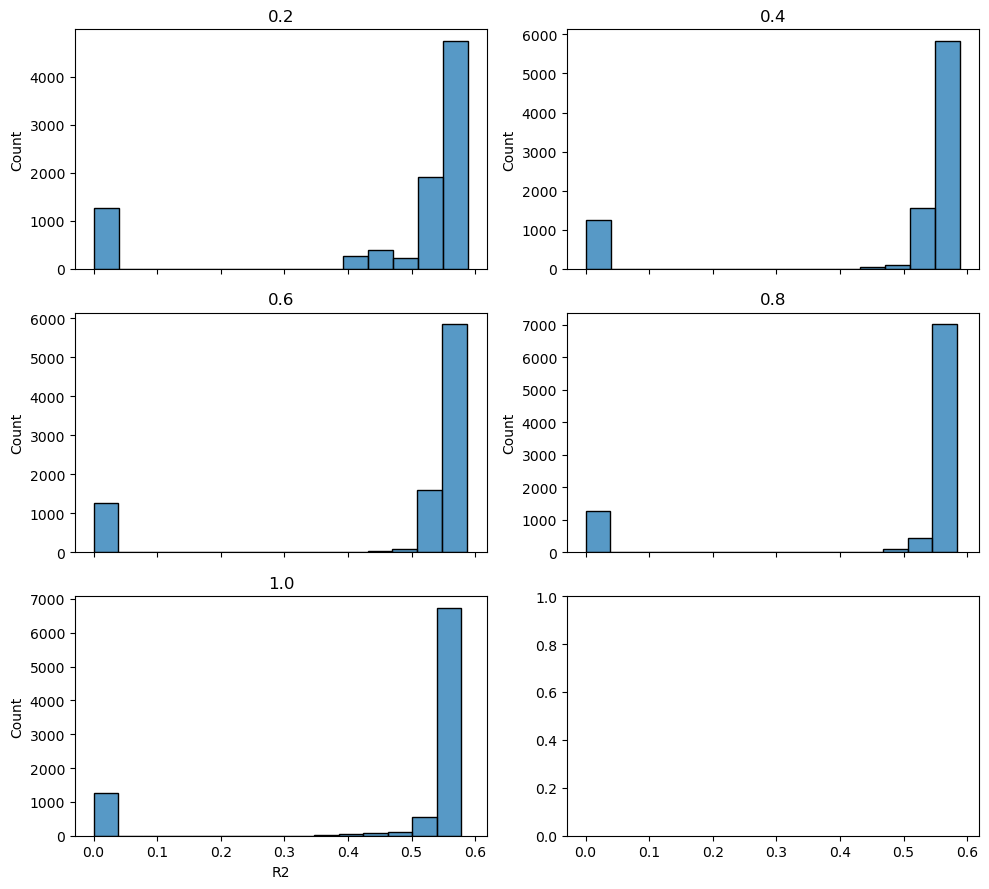

In [142]:
plot_histograms(round1_temp, 'subsample_frac', 15)

Range for `subsample_frac`: $[0.2, 0.8]$

In [143]:
round1_temp.groupby('eta')['val_r2_mean'].max()

eta
0.001    0.588533
0.010    0.589215
0.050    0.587438
0.100    0.584566
0.300    0.576397
Name: val_r2_mean, dtype: float64

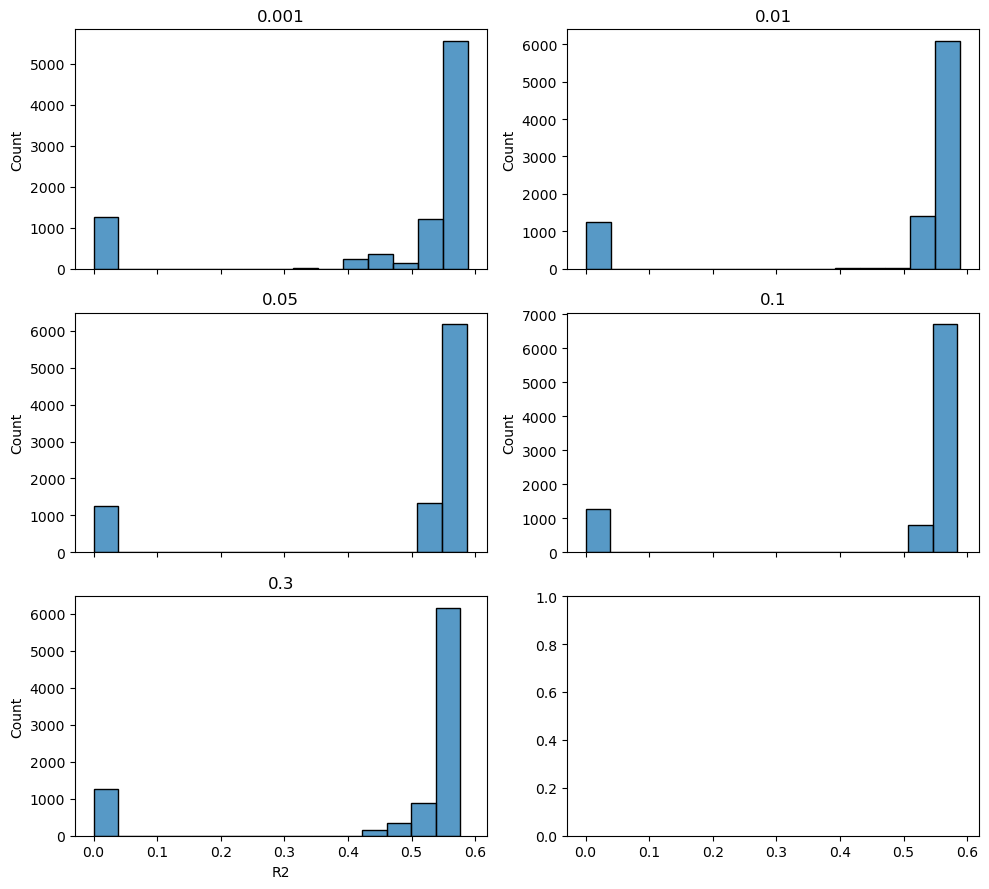

In [144]:
plot_histograms(round1_temp, 'eta', 15)

Good range for `eta`: $[0.001, 0.05]$.

#### Temp Round 1 Conclusions

+ `eta`: $[0.001, 0.05]$
+ `subsample_frac`: $[0.2, 0.8]$
+ `reg_lambda`: $[0,10]$ (but more evenly spaced than before)
+ `max_depth`: $[3, 10]$
+ `gamma`: $[1, 500]$
+ `min_child_weight`: $[0,25]$

### Round 2: Temp

In [36]:
with open('rounds/temp_round2_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [40]:
round2_temp = pd.read_csv('rounds/temp_xgb_round2.csv', index_col=False)

In [41]:
round2_temp.iloc[round2_temp.val_r2_mean.idxmax()]

Unnamed: 0                 15381.000000
gamma                         50.000000
max_depth                      5.000000
reg_lambda                     0.050000
min_child_weight               0.000000
subsample_frac                 0.300000
eta                            0.005000
num_boost                    947.000000
shrinkage_factor               1.009285
val_rmse_mean                  5.071612
val_r2_mean                    0.590225
test-r2-mean-ols-shrunk        0.513920
test-r2-mean-ols               0.513900
Name: 15381, dtype: float64

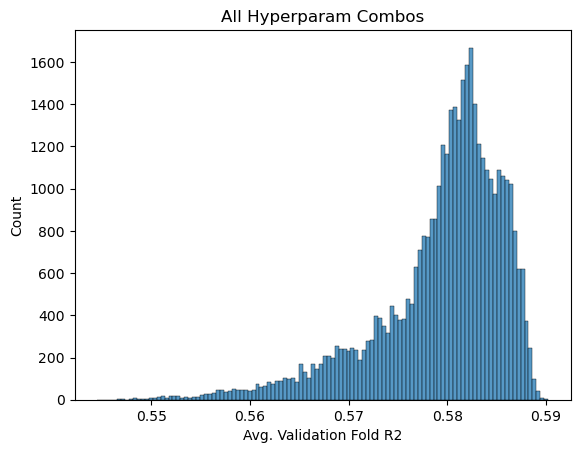

In [42]:
sns.histplot(data=round2_temp, x='val_r2_mean');
plt.title('All Hyperparam Combos')
plt.xlabel('Avg. Validation Fold R2');

In [43]:
round2_temp.groupby('min_child_weight')['val_r2_mean'].max()

min_child_weight
0.0    0.590225
1.0    0.590225
2.0    0.589873
3.0    0.589715
4.0    0.589183
5.0    0.588631
Name: val_r2_mean, dtype: float64

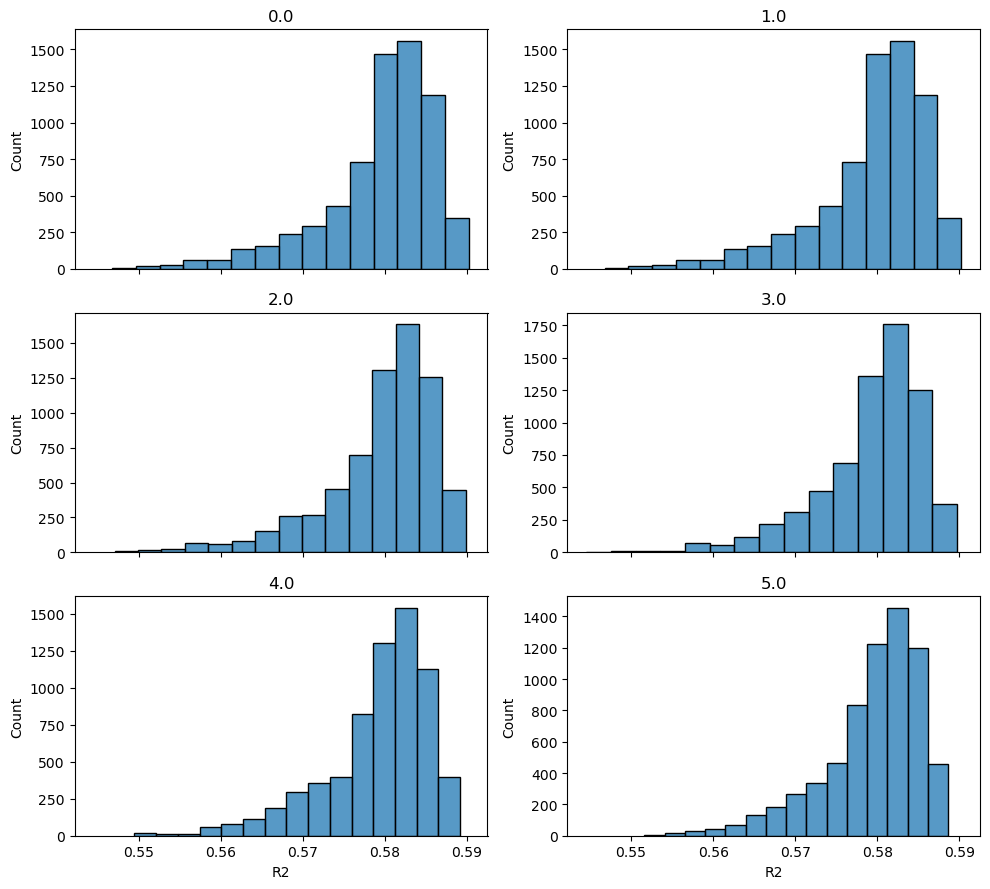

In [44]:
plot_histograms(round2_temp, 'min_child_weight', 15)

Good range for `min_child_weight`: $[0,2]$.

In [45]:
round2_temp.groupby('gamma')['val_r2_mean'].max()

gamma
1.0      0.589873
10.0     0.589841
50.0     0.590225
100.0    0.589468
150.0    0.589493
200.0    0.588879
Name: val_r2_mean, dtype: float64

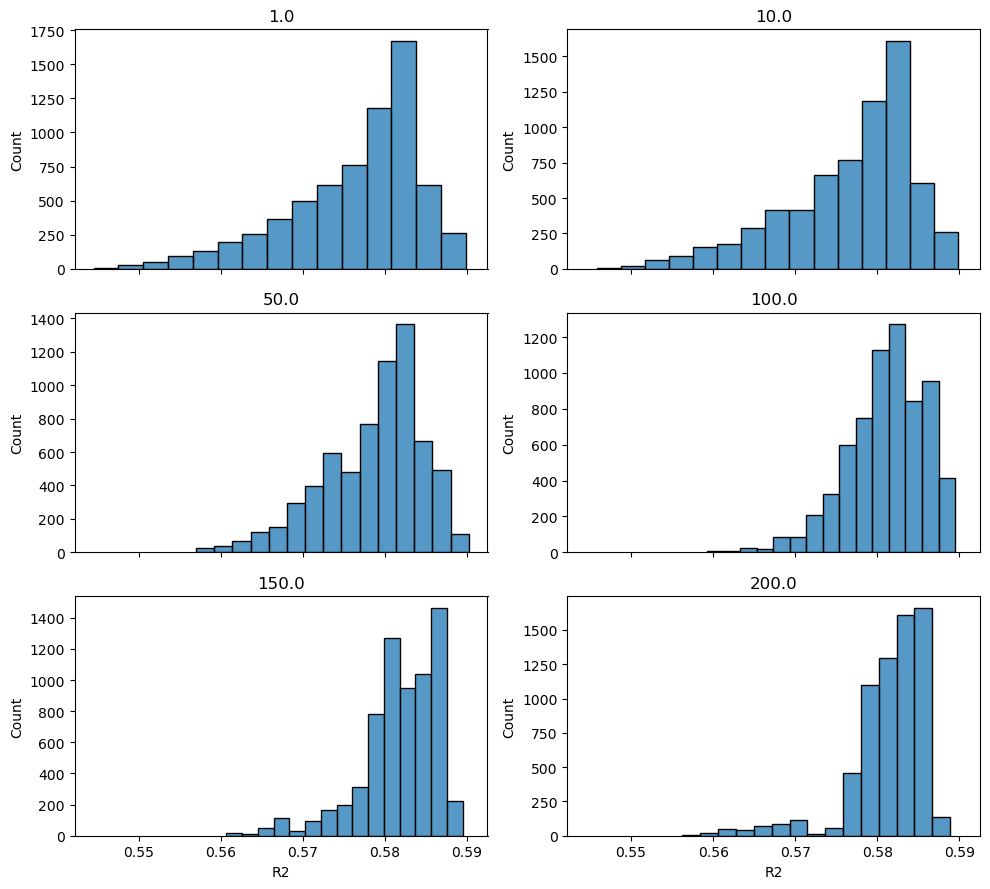

In [51]:
plot_histograms(round2_temp, 'gamma', 15)

Good range for `gamma`: $[10,100]$.

In [49]:
round2_temp.groupby('max_depth')['val_r2_mean'].max()

max_depth
3.0     0.585034
5.0     0.590225
7.0     0.589468
8.0     0.589335
10.0    0.589493
Name: val_r2_mean, dtype: float64

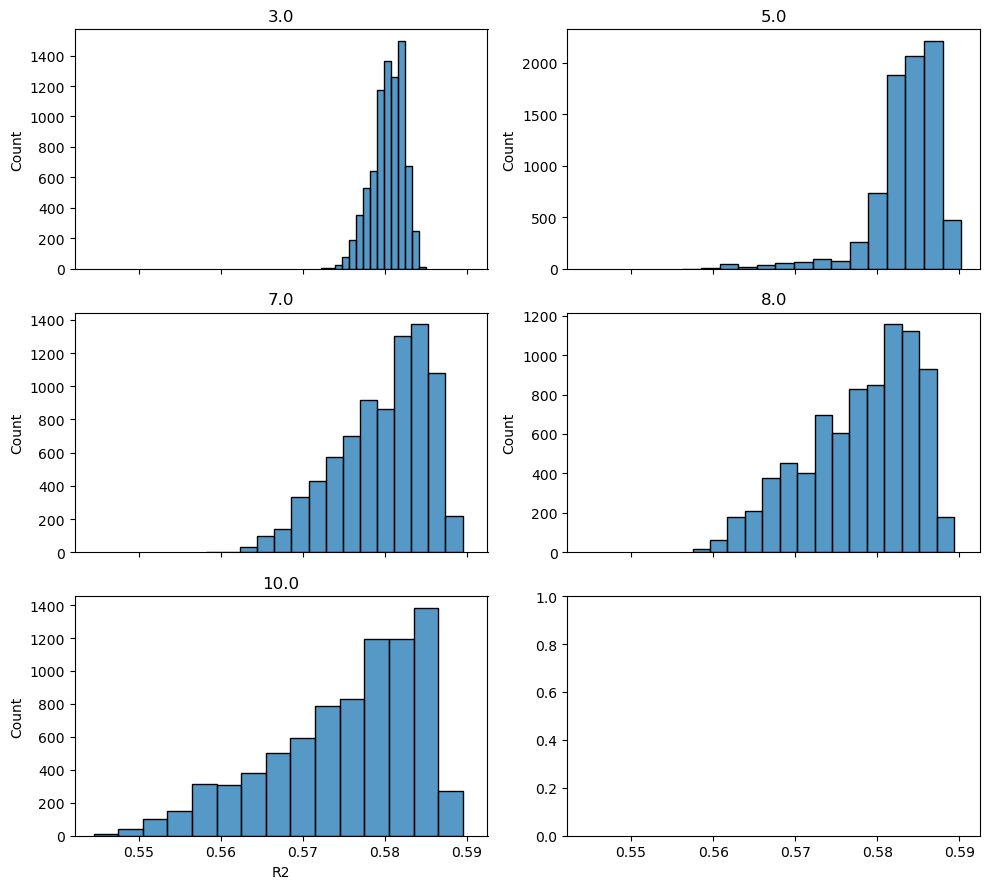

In [50]:
plot_histograms(round2_temp, 'max_depth', 15)

Best `max_depth` appear between $3$ and $7$

In [52]:
round2_temp.groupby('reg_lambda')['val_r2_mean'].max()

reg_lambda
0.000    0.589329
0.001    0.589215
0.005    0.589468
0.010    0.589158
0.050    0.590225
0.100    0.589873
0.500    0.589715
1.000    0.589171
Name: val_r2_mean, dtype: float64

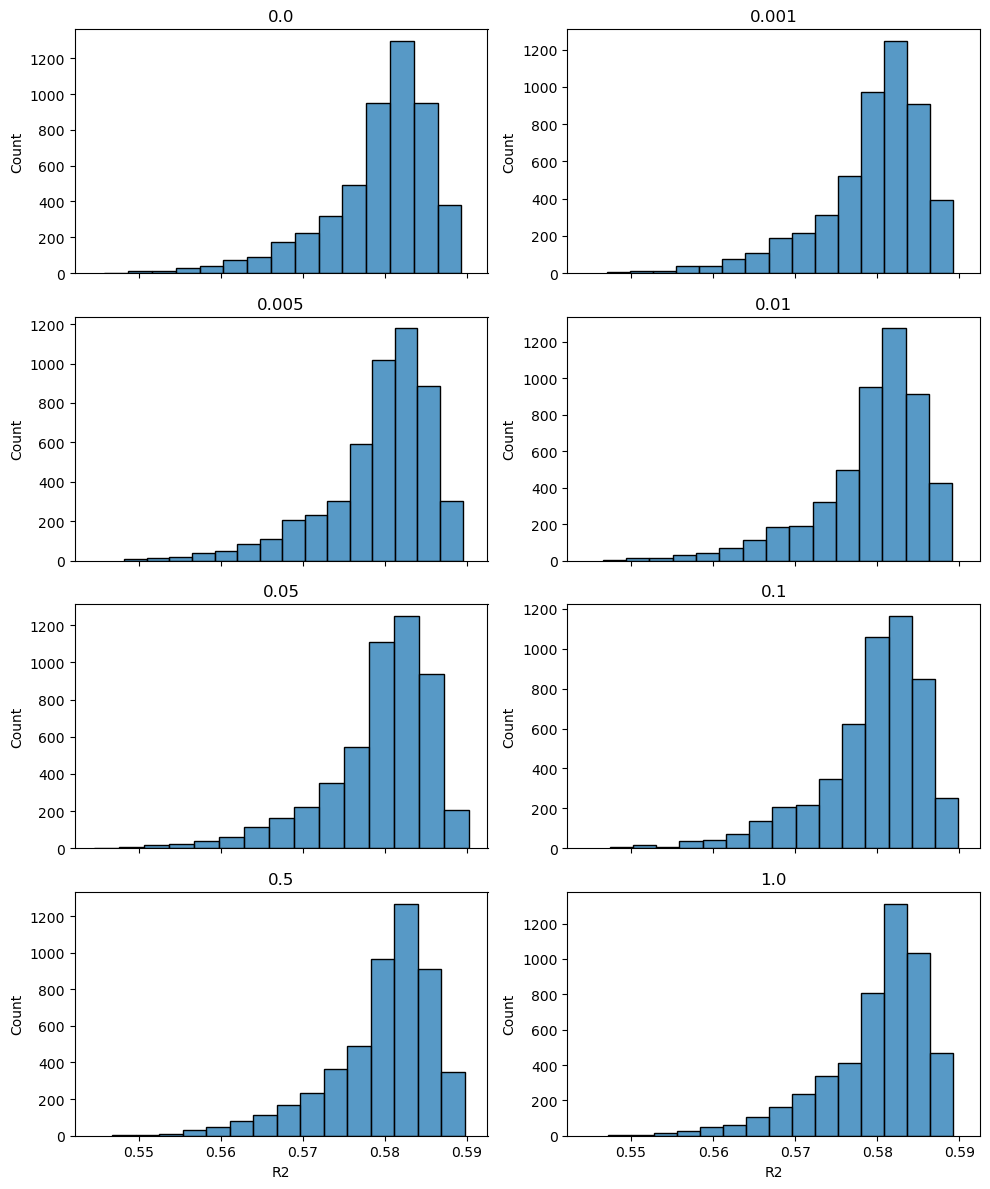

In [53]:
plot_histograms(round2_temp, 'reg_lambda', 15)

Best `reg_lambda` between $[0.01,0.1]$.

In [54]:
round2_temp.groupby('subsample_frac')['val_r2_mean'].max()

subsample_frac
0.2    0.589873
0.3    0.590225
0.4    0.589171
0.5    0.589493
0.6    0.586855
0.7    0.586452
0.8    0.584280
Name: val_r2_mean, dtype: float64

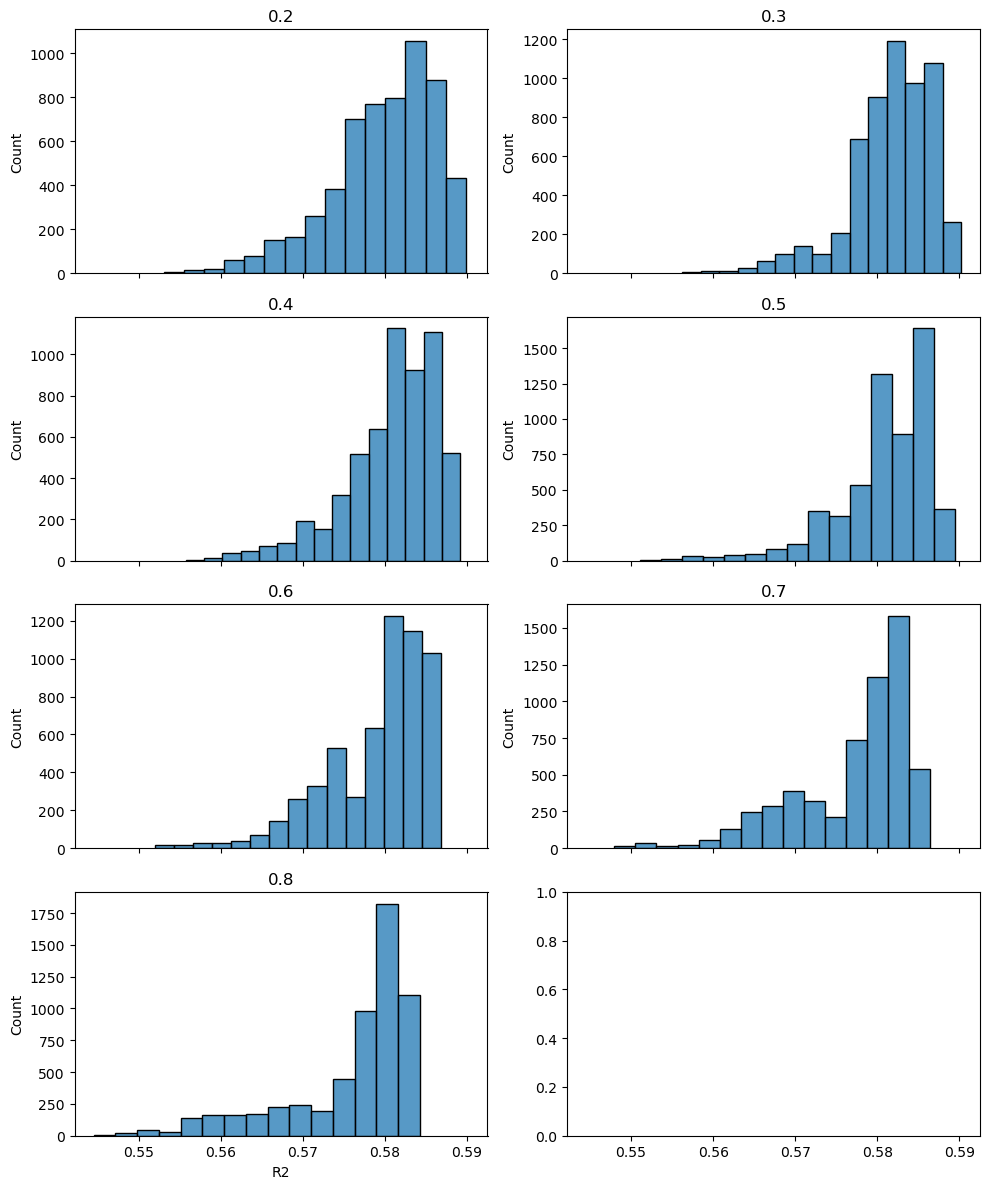

In [55]:
plot_histograms(round2_temp, 'subsample_frac', 15)

Range for `subsample_frac`: $[0.2, 0.5]$

In [56]:
round2_temp.groupby('eta')['val_r2_mean'].max()

eta
0.001    0.589522
0.005    0.590225
0.010    0.589873
0.050    0.588879
Name: val_r2_mean, dtype: float64

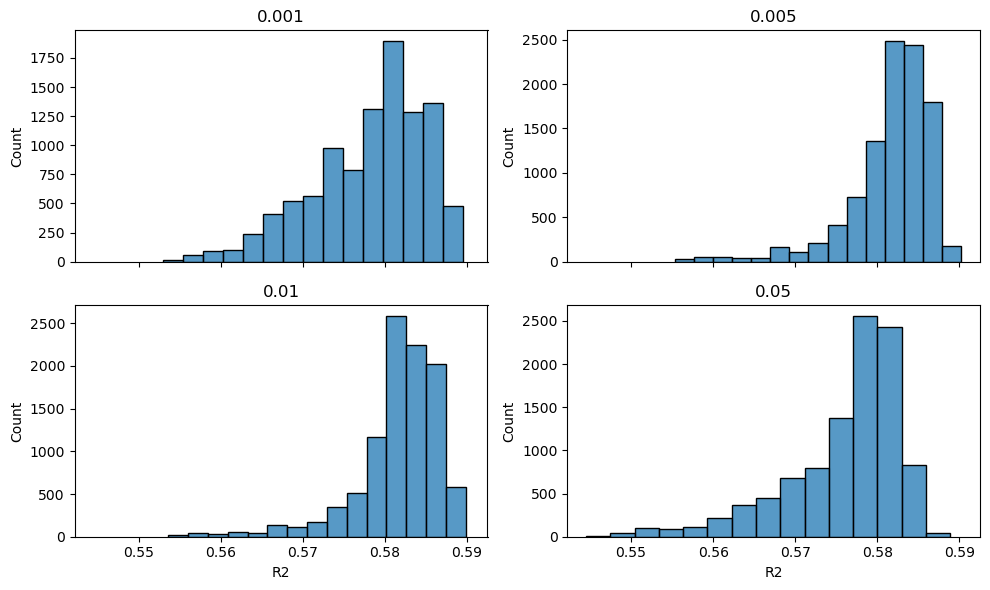

In [57]:
plot_histograms(round2_temp, 'eta', 15)

Good range for `eta`: $[0.001, 0.005, 0.01]$.

#### Temp Round 2 Conclusions

+ `eta`: $[0.001, 0.005, 0.05]$
+ `subsample_frac`: $[0.2, 0.5]$
+ `reg_lambda`: $[0.01,0.1]$ (but more evenly spaced than before)
+ `max_depth`: $[3, 7]$
+ `gamma`: $[10, 100]$
+ `min_child_weight`: $[0,2]$

### Round 3: Temp

In [10]:
round3_temp = pd.read_csv('rounds/temp_xgb_round3.csv', index_col=False)

In [11]:
best_performer = round3_temp.iloc[round3_snow['val_r2_mean'].idxmax()]
best_performer = best_performer[['gamma', 'max_depth', 'reg_lambda', 'min_child_weight', 'subsample_frac', 'eta', 'num_boost', 'shrinkage_factor']]

In [12]:
with open("best_temp_xgb.json", "w") as json_file:
    json.dump(best_performer.to_dict(), json_file, indent=4)